# H-R and CMD spread-metric analysis
Jupytext percent-format script. Convert with:
`jupytext --to notebook cmd_spread_analysis.py`

This script:
1. builds 1--20 Myr isochrones in 0.5 Myr steps for F070W/F182M/F200W;
2. plots the full H-R/CMD isochrone grids;
3. plots snapshot evolution at 1, 5, 10, 15, and 20 Myr;
4. measures the quartile spread in H-R and both CMD spaces;
5. plots each spread metric against simulation time.

In [1]:
from __future__ import annotations

import contextlib
import io
import math
import os
import shutil
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Column, Table
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from spisea import atmospheres, reddening, synthetic
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/home/wyz5rge/synthetic-cmd-dev/cmd_generator')
import interpolator  # noqa: E402

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
UPDATED_MERGED_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/'
    'baraffe_pisa_ekstrom_parsec/'
)

SIM_PATH = Path(
    '/standard/Tan_JC/backup_protoclusters/multiples/'
    'M3000new/sigma0p1/fiducial/sfe_ff003/00'
)

ISO_CACHE_DIR = Path.cwd() / 'isochrone_cache'
OUTPUT_DIR = Path.cwd() / 'cmd_spread_outputs'
RESET_ISO_CACHE = False
SAVE_FIGURES = True
SHOW_FIGURES = True

USE_ROTATING_MERGED = False
AKS = 0.0
DISTANCE_PC = 410.0
METALLICITY = 0.0
ATM_FUNC = atmospheres.get_BTSettl_2015_atmosphere
RED_LAW = reddening.RedLawHosek18b()

ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
ISO_LOG_AGES = np.log10(ISO_AGES_MYR * 1e6)
EVOLUTION_TIMES_MYR = np.array([1.0, 5.0, 10.0, 15.0, 20.0])
ANALYSIS_TIMES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)

TEFF_MIN_K = 3000.0
TEFF_MAX_K = 3600.0
N_BINS = 6
TEFF_BIN_EDGES_K = np.linspace(TEFF_MIN_K, TEFF_MAX_K, N_BINS + 1)
MIN_STARS_PER_BIN = 8
QUARTILE_FRACTION = 0.25
L_SUN_WATTS = 3.846e26

ALL_FILTERS = ['jwst,F070W', 'jwst,F182M', 'jwst,F200W']
FILTER_KEYS = {
    'F070W': 'm_jwst_F070W',
    'F182M': 'm_jwst_F182M',
    'F200W': 'm_jwst_F200W',
}
CMD_CONFIGS = {
    'F070W-F200W': {
        'filter_a': 'F070W', 'filter_b': 'F200W', 'y_filter': 'F200W',
        'color_label': 'F070W - F200W', 'y_label': 'F200W',
        'color_column': 'color_F070W_F200W',
    },
    'F182M-F200W': {
        'filter_a': 'F182M', 'filter_b': 'F200W', 'y_filter': 'F200W',
        'color_label': 'F182M - F200W', 'y_label': 'F200W',
        'color_column': 'color_F182M_F200W',
    },
}

## Merged-model ASCII compatibility reader

In [3]:
class MergedBaraffePisaEkstromParsecDAT:
    def __init__(self, root_dir: Path | str, rot: bool = False):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)
        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []
        self.grid_dir = self.root_dir / ('z015_rot' if self.rot else 'z015_norot')
        if not self.grid_dir.is_dir():
            raise FileNotFoundError(f'Model directory not found: {self.grid_dir}')
        self.age_file_map = {}
        for path in sorted(self.grid_dir.glob('iso_*.dat')):
            try:
                log_age = float(path.stem.split('_')[1])
            except (IndexError, ValueError):
                continue
            self.age_file_map[round(log_age, 2)] = path
        if not self.age_file_map:
            raise FileNotFoundError(f'No iso_*.dat files found in {self.grid_dir}')
        self.age_list = np.array(sorted(self.age_file_map), dtype=float)

    def isochrone(self, age: float = 1e6, metallicity: float = 0.0) -> Table:
        log_age_requested = math.log10(age)
        if not self.age_list[0] <= log_age_requested <= self.age_list[-1]:
            raise ValueError(
                f'logAge={log_age_requested:.4f} outside '
                f'{self.age_list[0]:.2f}--{self.age_list[-1]:.2f}'
            )
        idx = int(np.argmin(np.abs(self.age_list - log_age_requested)))
        selected_log_age = float(self.age_list[idx])
        iso_path = self.age_file_map[round(selected_log_age, 2)]
        dtype = [
            ('mass', 'f8'), ('logT', 'f8'), ('logL', 'f8'), ('logg', 'f8'),
            ('logT_WR', 'f8'), ('mass_current', 'f8'), ('phase', 'i4'),
            ('model_ref', 'U32'),
        ]
        data = np.genfromtxt(iso_path, comments='#', dtype=dtype, encoding='utf-8')
        iso = Table(np.atleast_1d(data))
        is_wr = ~np.isclose(
            np.asarray(iso['logT'], float), np.asarray(iso['logT_WR'], float),
            rtol=0.0, atol=1e-8,
        )
        iso.add_column(Column(is_wr, name='isWR'))
        iso.meta.update({
            'log_age': selected_log_age,
            'log_age_requested': log_age_requested,
            'metallicity_in': metallicity,
            'metallicity_act': 0.0,
            'source_file': str(iso_path),
        })
        return iso

## Helpers and data structures

In [4]:
@dataclass
class IsochroneGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    coverage: pd.DataFrame


@dataclass
class SpreadResult:
    metric: float
    bin_spreads: np.ndarray
    bin_counts: np.ndarray
    n_valid_bins: int
    n_stars_in_band: int


def prepare_dirs() -> None:
    if RESET_ISO_CACHE and ISO_CACHE_DIR.exists():
        shutil.rmtree(ISO_CACHE_DIR)
    ISO_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def finish_figure(fig: plt.Figure, filename: str) -> None:
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / filename, dpi=200, bbox_inches='tight')
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def get_iso_column(iso, name: str) -> np.ndarray:
    return np.asarray(iso.points[name], float)


def get_hr_coordinates(iso):
    teff = get_iso_column(iso, 'Teff')
    log_lum = np.log10(get_iso_column(iso, 'L') / L_SUN_WATTS)
    mass = get_iso_column(iso, 'mass')
    good = np.isfinite(teff) & np.isfinite(log_lum) & np.isfinite(mass)
    return teff[good], log_lum[good], mass[good]


def get_cmd_coordinates(iso, config):
    a = get_iso_column(iso, FILTER_KEYS[config['filter_a']])
    b = get_iso_column(iso, FILTER_KEYS[config['filter_b']])
    y = get_iso_column(iso, FILTER_KEYS[config['y_filter']])
    mass = get_iso_column(iso, 'mass')
    color = a - b
    good = np.isfinite(color) & np.isfinite(y) & np.isfinite(mass)
    return color[good], y[good], mass[good]


def safe_interpolate(age_myr, mass, iso_grid, log_age_arr, filter_pair):
    try:
        with warnings.catch_warnings(), contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            warnings.simplefilter('ignore')
            out = interpolator.interpolate(age_myr, mass, iso_grid, log_age_arr, list(filter_pair))
        out = np.asarray(out, float)
        return out if out.size >= 5 and np.all(np.isfinite(out)) else None
    except Exception:
        return None

## Generate 1--20 Myr isochrones

In [5]:
def build_isochrone_grid(evo_model) -> IsochroneGrid:
    isochrones, records = [], []
    for age_myr, log_age in zip(ISO_AGES_MYR, ISO_LOG_AGES):
        print(f'Building {age_myr:4.1f} Myr isochrone')
        try:
            iso = synthetic.IsochronePhot(
                log_age, AKS, DISTANCE_PC,
                metallicity=METALLICITY,
                evo_model=evo_model,
                atm_func=ATM_FUNC,
                red_law=RED_LAW,
                filters=ALL_FILTERS,
                iso_dir=str(ISO_CACHE_DIR),
            )
            missing = [k for k in FILTER_KEYS.values() if k not in iso.points.colnames]
            if missing:
                raise KeyError(f'Missing photometric columns: {missing}')
            masses = get_iso_column(iso, 'mass')
            isochrones.append(iso)
            records.append({
                'age_myr': age_myr, 'status': 'success', 'n_points': len(iso.points),
                'mass_min': np.nanmin(masses), 'mass_max': np.nanmax(masses), 'error': '',
            })
        except Exception as exc:
            isochrones.append(None)
            records.append({
                'age_myr': age_myr, 'status': 'failed', 'n_points': 0,
                'mass_min': np.nan, 'mass_max': np.nan, 'error': str(exc),
            })
    return IsochroneGrid(ISO_AGES_MYR.copy(), ISO_LOG_AGES.copy(), isochrones, pd.DataFrame(records))


prepare_dirs()
evo_model = MergedBaraffePisaEkstromParsecDAT(UPDATED_MERGED_ROOT, USE_ROTATING_MERGED)
ISO_GRID = build_isochrone_grid(evo_model)
display(ISO_GRID.coverage)
if ISO_GRID.coverage['status'].ne('success').any():
    raise RuntimeError('At least one photometric isochrone failed. See the coverage table.')

Building  1.0 Myr isochrone


Building  1.5 Myr isochrone
Building  2.0 Myr isochrone
Building  2.5 Myr isochrone
Building  3.0 Myr isochrone
Building  3.5 Myr isochrone
Building  4.0 Myr isochrone
Building  4.5 Myr isochrone
Building  5.0 Myr isochrone
Building  5.5 Myr isochrone
Building  6.0 Myr isochrone
Building  6.5 Myr isochrone
Building  7.0 Myr isochrone
Building  7.5 Myr isochrone
Building  8.0 Myr isochrone
Building  8.5 Myr isochrone


Building  9.0 Myr isochrone


Building  9.5 Myr isochrone
Building 10.0 Myr isochrone
Building 10.5 Myr isochrone
Building 11.0 Myr isochrone
Building 11.5 Myr isochrone
Building 12.0 Myr isochrone
Building 12.5 Myr isochrone
Building 13.0 Myr isochrone
Building 13.5 Myr isochrone
Building 14.0 Myr isochrone
Building 14.5 Myr isochrone
Building 15.0 Myr isochrone
Building 15.5 Myr isochrone
Building 16.0 Myr isochrone
Building 16.5 Myr isochrone


Building 17.0 Myr isochrone


Building 17.5 Myr isochrone
Building 18.0 Myr isochrone
Building 18.5 Myr isochrone
Building 19.0 Myr isochrone
Building 19.5 Myr isochrone
Building 20.0 Myr isochrone


,age_myr,status,n_points,mass_min,mass_max,error
0,1.0,success,1178,0.01,500.000,
1,1.5,success,1287,0.01,500.000,
2,2.0,success,1330,0.01,500.000,
3,2.5,success,2333,0.01,259.154,
4,3.0,success,1856,0.01,116.520,
5,3.5,success,1884,0.01,80.336,
6,4.0,success,1704,0.01,58.761,
7,4.5,success,1571,0.01,47.174,
8,5.0,success,1529,0.01,39.109,
9,5.5,success,1525,0.01,34.304,


## Full three-panel theoretical grid

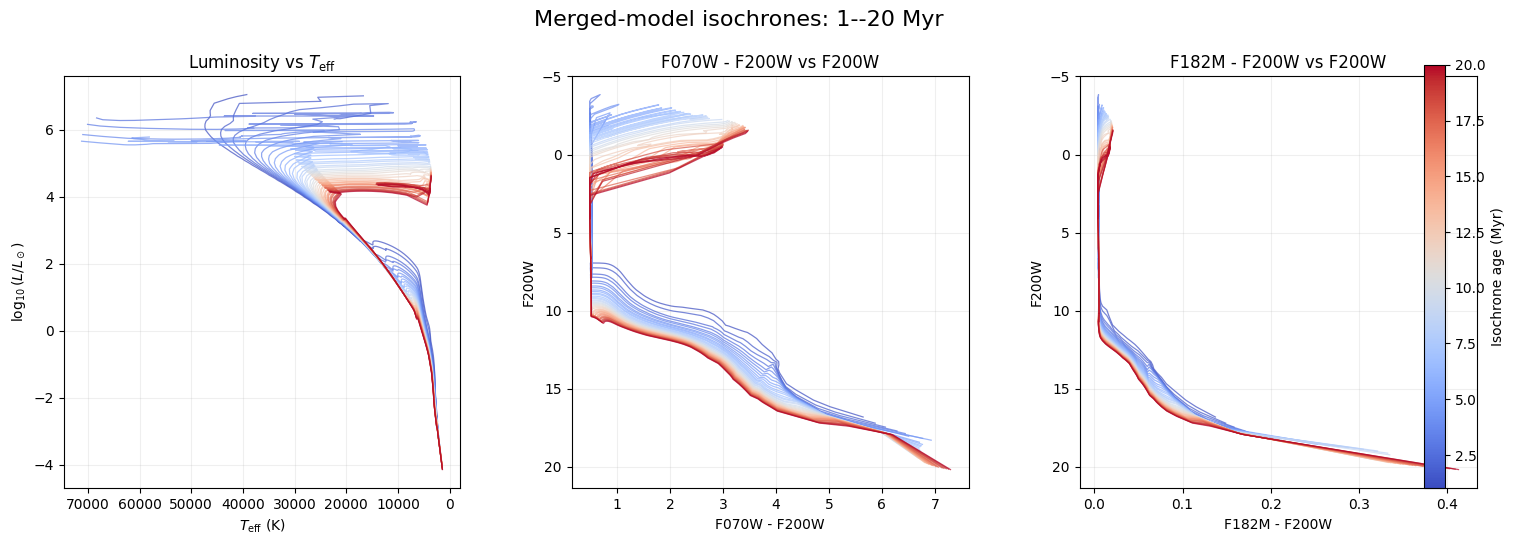

In [6]:
def plot_full_isochrone_grid(grid: IsochroneGrid) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(grid.ages_myr.min(), grid.ages_myr.max())
    for iso, age in zip(grid.isochrones, grid.ages_myr):
        c = cmap(norm(age))
        x, y, _ = get_hr_coordinates(iso)
        axes[0].plot(x, y, color=c, lw=0.9, alpha=0.7)
        for ax, config in zip(axes[1:], CMD_CONFIGS.values()):
            x, y, _ = get_cmd_coordinates(iso, config)
            ax.plot(x, y, color=c, lw=0.9, alpha=0.7)
    axes[0].set(title=r'Luminosity vs $T_{\rm eff}$', xlabel=r'$T_{\rm eff}$ (K)', ylabel=r'$\log_{10}(L/L_\odot)$')
    axes[0].invert_xaxis()
    for ax, config in zip(axes[1:], CMD_CONFIGS.values()):
        ax.set(title=f"{config['color_label']} vs {config['y_label']}", xlabel=config['color_label'], ylabel=config['y_label'])
        ax.invert_yaxis()
    for ax in axes:
        ax.grid(alpha=0.2)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    fig.colorbar(sm, ax=axes.tolist(), pad=0.015, fraction=0.025, label='Isochrone age (Myr)')
    fig.suptitle('Merged-model isochrones: 1--20 Myr', fontsize=16)
    fig.subplots_adjust(top=0.86, right=0.91, wspace=0.28)
    finish_figure(fig, '01_full_isochrone_grid.png')


plot_full_isochrone_grid(ISO_GRID)

## Fixed equal-color bin edges from the 1 Myr isochrone

In [7]:
def color_at_temperature(iso, config, target_teff_k: float) -> float:
    teff = get_iso_column(iso, 'Teff')
    color = (
        get_iso_column(iso, FILTER_KEYS[config['filter_a']])
        - get_iso_column(iso, FILTER_KEYS[config['filter_b']])
    )
    good = np.isfinite(teff) & np.isfinite(color)
    teff, color = teff[good], color[good]
    local = (teff >= TEFF_MIN_K - 250) & (teff <= TEFF_MAX_K + 250)
    teff, color = teff[local], color[local]
    order = np.argsort(teff)
    teff, color = teff[order], color[order]
    teff, idx = np.unique(teff, return_index=True)
    color = color[idx]
    if teff.size < 2 or not teff.min() <= target_teff_k <= teff.max():
        raise ValueError(f'Cannot interpolate color at {target_teff_k:.0f} K')
    return float(np.interp(target_teff_k, teff, color))


def define_cmd_bin_edges(grid: IsochroneGrid):
    idx_1myr = int(np.argmin(np.abs(grid.ages_myr - 1.0)))
    iso = grid.isochrones[idx_1myr]
    edges = {}
    for name, config in CMD_CONFIGS.items():
        c3000 = color_at_temperature(iso, config, 3000.0)
        c3600 = color_at_temperature(iso, config, 3600.0)
        edges[name] = np.linspace(min(c3000, c3600), max(c3000, c3600), N_BINS + 1)
        print(f'{name}: C3000={c3000:.6f}, C3600={c3600:.6f}')
        print(edges[name])
    return edges


CMD_BIN_EDGES = define_cmd_bin_edges(ISO_GRID)
rows = []
for space, edges in {'H-R': TEFF_BIN_EDGES_K, **CMD_BIN_EDGES}.items():
    for i in range(N_BINS):
        rows.append({'space': space, 'bin': i + 1, 'lower_edge': edges[i], 'upper_edge': edges[i + 1]})
pd.DataFrame(rows).to_csv(OUTPUT_DIR / 'fixed_bin_edges.csv', index=False)

F070W-F200W: C3000=3.912096, C3600=3.100327
[3.10032659 3.23562144 3.37091628 3.50621113 3.64150597 3.77680082
 3.91209566]
F182M-F200W: C3000=0.054384, C3600=0.021727
[0.02172692 0.02716978 0.03261263 0.03805548 0.04349834 0.04894119
 0.05438405]


## Load and interpolate cluster snapshots

In [8]:
def load_cluster_table(sim_path: Path | str, snapshot_time_myr: float) -> Table:
    path = os.path.abspath(str(sim_path))
    if not path.endswith('/'):
        path += '/'
    snapshot = Reader.read_snapshot(path, time=float(snapshot_time_myr))
    snapshot.to_physical()
    return converter.to_spicea_table(snapshot)


def interpolate_cluster_snapshot(cluster_table: Table, grid: IsochroneGrid) -> pd.DataFrame:
    rows = []
    masses = np.asarray(cluster_table['mass'], float)
    ages = np.asarray(cluster_table['age'], float)
    for system_index, (mass, age) in enumerate(zip(masses, ages)):
        if not np.isfinite(mass) or not np.isfinite(age) or not grid.ages_myr.min() <= age <= grid.ages_myr.max():
            continue
        a = safe_interpolate(age, mass, grid.isochrones, grid.log_ages, [FILTER_KEYS['F070W'], FILTER_KEYS['F200W']])
        b = safe_interpolate(age, mass, grid.isochrones, grid.log_ages, [FILTER_KEYS['F182M'], FILTER_KEYS['F200W']])
        if a is None or b is None:
            continue
        lum_w, teff, logg, mag070, mag200a = a[:5]
        _, _, _, mag182, mag200b = b[:5]
        mag200 = 0.5 * (mag200a + mag200b)
        rows.append({
            'system_index': system_index, 'mass': mass, 'age_myr': age,
            'teff': teff, 'logg': logg,
            'luminosity_watts': lum_w,
            'log_luminosity_lsun': np.log10(lum_w / L_SUN_WATTS),
            'mag_F070W': mag070, 'mag_F182M': mag182, 'mag_F200W': mag200,
            'color_F070W_F200W': mag070 - mag200,
            'color_F182M_F200W': mag182 - mag200,
        })
    return pd.DataFrame(rows)


def load_and_interpolate_snapshot(sim_path, time_myr, grid):
    table = load_cluster_table(sim_path, time_myr)
    df = interpolate_cluster_snapshot(table, grid)
    print(f't={time_myr:4.1f} Myr: retained {len(df)}/{len(table)} systems')
    return df

## Five-panel snapshot evolution for each coordinate system

t= 1.0 Myr: retained 103/543 systems


t= 5.0 Myr: retained 1911/2329 systems


t=10.0 Myr: retained 2881/2917 systems


t=15.0 Myr: retained 2896/2934 systems


t=20.0 Myr: retained 2791/2940 systems


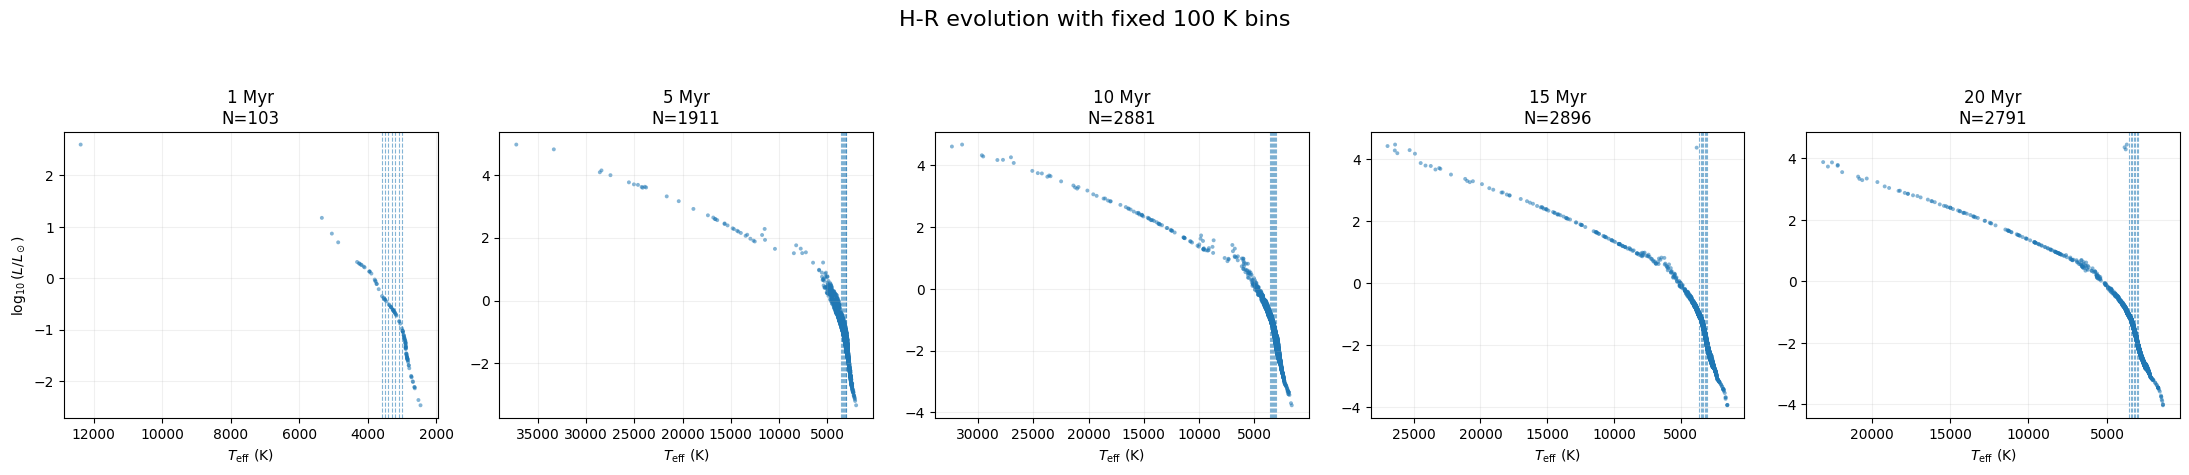

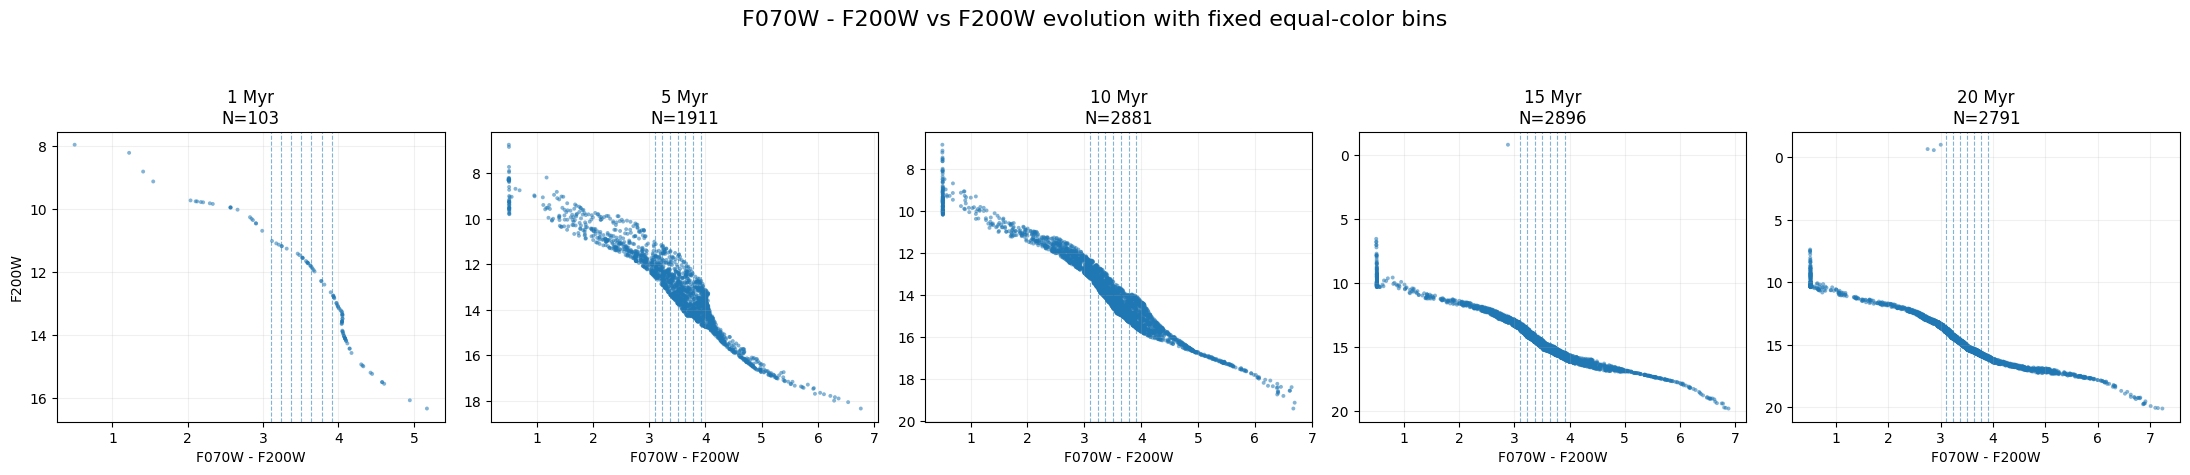

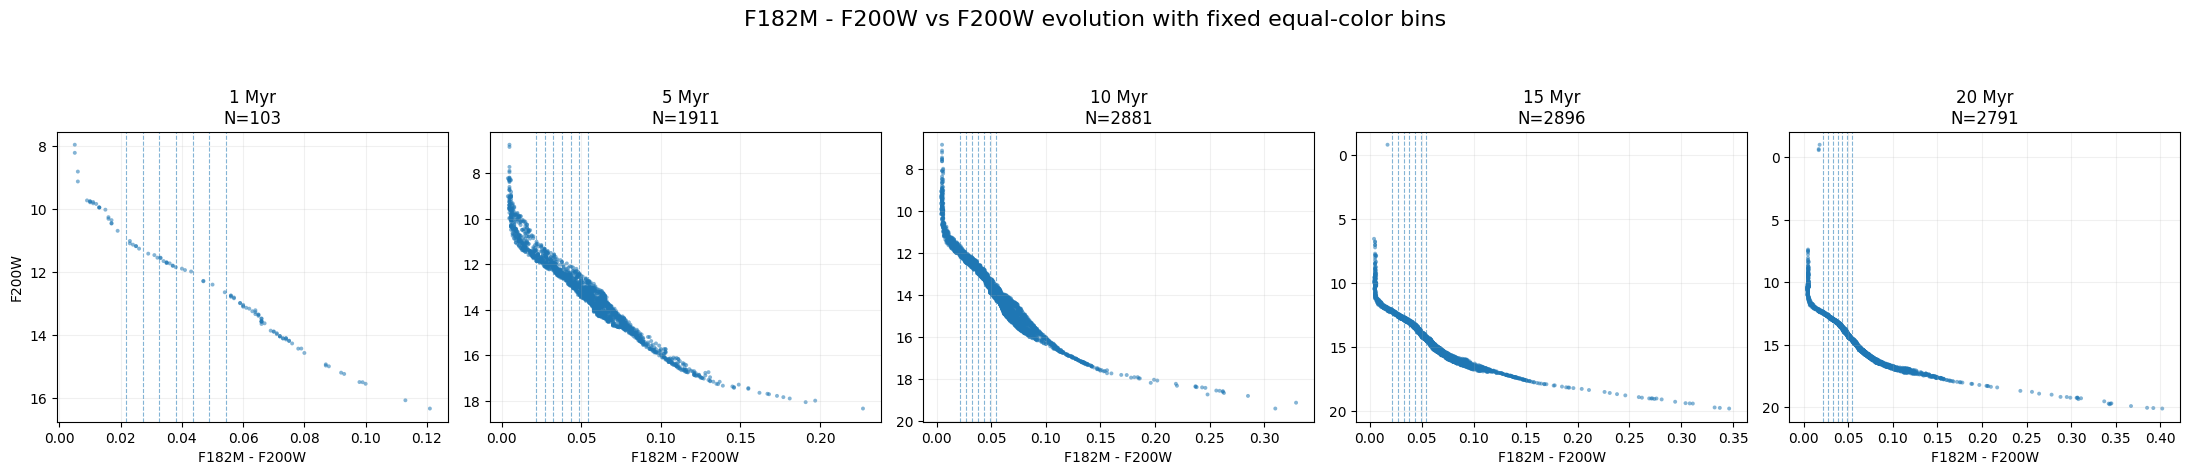

In [9]:
def plot_hr_evolution(snapshots):
    fig, axes = plt.subplots(1, len(EVOLUTION_TIMES_MYR), figsize=(22, 4.8))
    for ax, t in zip(axes, EVOLUTION_TIMES_MYR):
        df = snapshots[float(t)]
        ax.scatter(df['teff'], df['log_luminosity_lsun'], s=8, alpha=0.55, edgecolors='none')
        for edge in TEFF_BIN_EDGES_K:
            ax.axvline(edge, ls='--', lw=0.8, alpha=0.55)
        ax.set_title(f'{t:g} Myr\nN={len(df)}'); ax.set_xlabel(r'$T_{\rm eff}$ (K)'); ax.invert_xaxis(); ax.grid(alpha=0.18)
    axes[0].set_ylabel(r'$\log_{10}(L/L_\odot)$')
    fig.suptitle('H-R evolution with fixed 100 K bins', fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.92)); finish_figure(fig, '02_hr_snapshot_evolution.png')


def plot_cmd_evolution(snapshots, cmd_name):
    config, edges = CMD_CONFIGS[cmd_name], CMD_BIN_EDGES[cmd_name]
    fig, axes = plt.subplots(1, len(EVOLUTION_TIMES_MYR), figsize=(22, 4.8))
    for ax, t in zip(axes, EVOLUTION_TIMES_MYR):
        df = snapshots[float(t)]
        ax.scatter(df[config['color_column']], df['mag_F200W'], s=8, alpha=0.55, edgecolors='none')
        for edge in edges:
            ax.axvline(edge, ls='--', lw=0.8, alpha=0.55)
        ax.set_title(f'{t:g} Myr\nN={len(df)}'); ax.set_xlabel(config['color_label']); ax.invert_yaxis(); ax.grid(alpha=0.18)
    axes[0].set_ylabel('F200W')
    fig.suptitle(f"{config['color_label']} vs F200W evolution with fixed equal-color bins", fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    finish_figure(fig, f"03_{cmd_name.lower().replace('-', '_')}_snapshot_evolution.png")


EVOLUTION_SNAPSHOTS = {
    float(t): load_and_interpolate_snapshot(SIM_PATH, t, ISO_GRID)
    for t in EVOLUTION_TIMES_MYR
}
plot_hr_evolution(EVOLUTION_SNAPSHOTS)
plot_cmd_evolution(EVOLUTION_SNAPSHOTS, 'F070W-F200W')
plot_cmd_evolution(EVOLUTION_SNAPSHOTS, 'F182M-F200W')

## Quartile spread metric

In [10]:
def quartile_spread_metric(horizontal, vertical, bin_edges, vertical_mode):
    horizontal, vertical = np.asarray(horizontal, float), np.asarray(vertical, float)
    good = np.isfinite(horizontal) & np.isfinite(vertical)
    horizontal, vertical = horizontal[good], vertical[good]
    bin_spreads = np.full(N_BINS, np.nan)
    bin_counts = np.zeros(N_BINS, int)
    in_band = (horizontal >= bin_edges[0]) & (horizontal <= bin_edges[-1])
    for i in range(N_BINS):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (horizontal >= lo) & ((horizontal <= hi) if i == N_BINS - 1 else (horizontal < hi))
        values = np.sort(vertical[mask])
        bin_counts[i] = len(values)
        if len(values) < MIN_STARS_PER_BIN:
            continue
        nq = max(1, int(np.floor(QUARTILE_FRACTION * len(values))))
        low_mean, high_mean = np.mean(values[:nq]), np.mean(values[-nq:])
        if vertical_mode not in {'luminosity', 'magnitude'}:
            raise ValueError("vertical_mode must be 'luminosity' or 'magnitude'")
        bin_spreads[i] = high_mean - low_mean
    valid = np.isfinite(bin_spreads)
    return SpreadResult(
        metric=float(np.nanmean(bin_spreads)) if valid.any() else np.nan,
        bin_spreads=bin_spreads,
        bin_counts=bin_counts,
        n_valid_bins=int(valid.sum()),
        n_stars_in_band=int(in_band.sum()),
    )


def measure_all_spaces(df):
    return {
        'H-R': quartile_spread_metric(df['teff'], df['log_luminosity_lsun'], TEFF_BIN_EDGES_K, 'luminosity'),
        'F070W-F200W': quartile_spread_metric(df['color_F070W_F200W'], df['mag_F200W'], CMD_BIN_EDGES['F070W-F200W'], 'magnitude'),
        'F182M-F200W': quartile_spread_metric(df['color_F182M_F200W'], df['mag_F200W'], CMD_BIN_EDGES['F182M-F200W'], 'magnitude'),
    }

## Spread metric versus time


Analyzing t=1.00 Myr


t= 1.0 Myr: retained 103/543 systems

Analyzing t=1.50 Myr


t= 1.5 Myr: retained 327/756 systems

Analyzing t=2.00 Myr


t= 2.0 Myr: retained 538/1003 systems

Analyzing t=2.50 Myr


t= 2.5 Myr: retained 753/1253 systems

Analyzing t=3.00 Myr


...

t=18.5 Myr: retained 2898/2939 systems

Analyzing t=19.00 Myr


t=19.0 Myr: retained 2898/2939 systems

Analyzing t=19.50 Myr


t=19.5 Myr: retained 2897/2939 systems

Analyzing t=20.00 Myr


t=20.0 Myr: retained 2791/2940 systems


,time_myr,space,spread_metric,n_valid_bins,n_stars_in_band,n_interpolated_stars
0,1.0,H-R,0.056923,1,26,103
1,1.0,F070W-F200W,0.254500,1,26,103
2,1.0,F182M-F200W,0.272500,1,26,103
3,1.5,H-R,0.153149,5,106,327
4,1.5,F070W-F200W,0.426924,5,108,327
5,1.5,F182M-F200W,0.249339,6,99,327
6,2.0,H-R,0.217847,6,185,538
7,2.0,F070W-F200W,0.690581,6,187,538
8,2.0,F182M-F200W,0.407173,6,174,538
9,2.5,H-R,0.253883,6,254,753


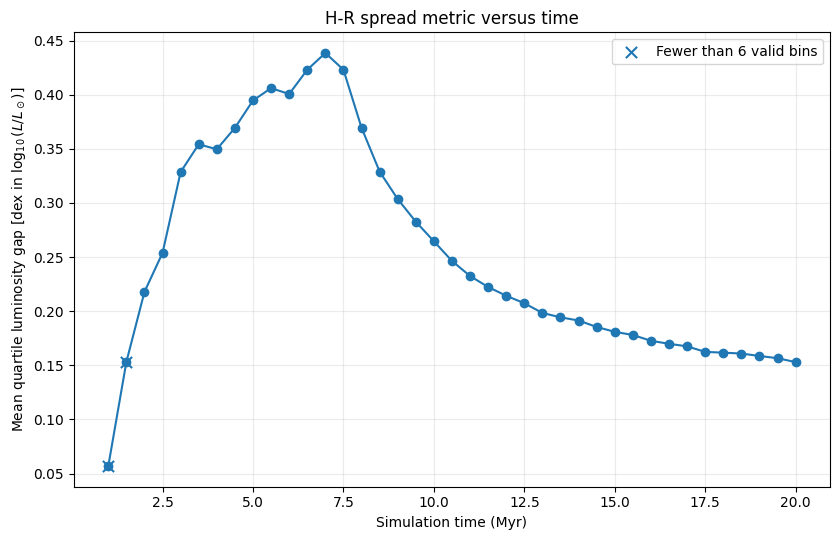

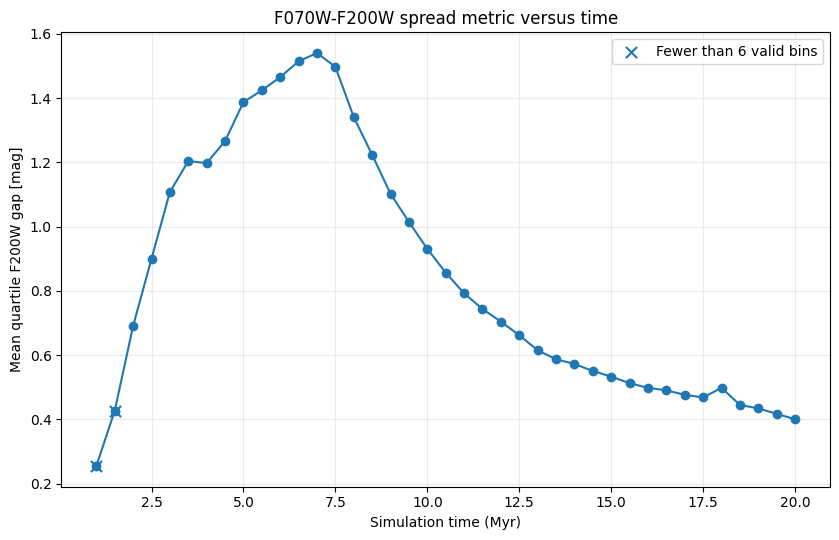

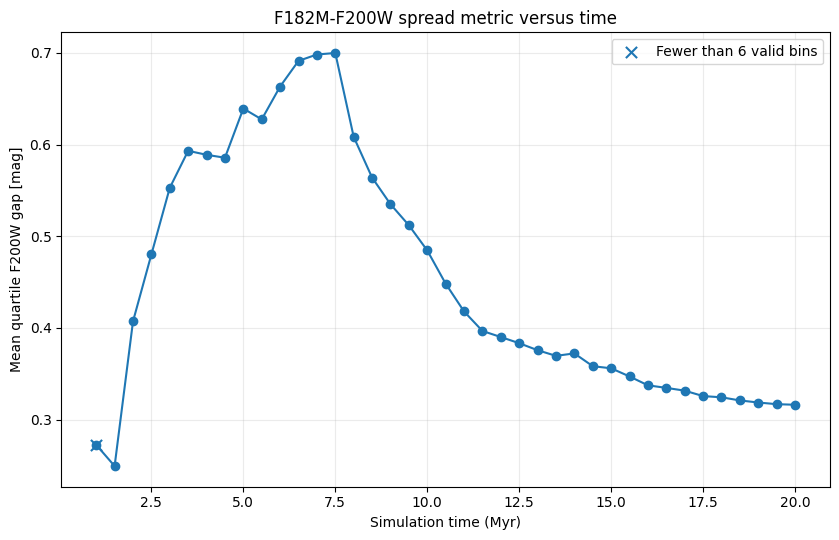

In [11]:
def run_spread_time_series(sim_path, times_myr: Iterable[float], grid):
    summary_rows, bin_rows = [], []
    for t in times_myr:
        print(f'\nAnalyzing t={t:.2f} Myr')
        df = load_and_interpolate_snapshot(sim_path, float(t), grid)
        for space, result in measure_all_spaces(df).items():
            summary_rows.append({
                'time_myr': float(t), 'space': space, 'spread_metric': result.metric,
                'n_valid_bins': result.n_valid_bins, 'n_stars_in_band': result.n_stars_in_band,
                'n_interpolated_stars': len(df),
            })
            for i, (spread, count) in enumerate(zip(result.bin_spreads, result.bin_counts), 1):
                bin_rows.append({'time_myr': float(t), 'space': space, 'bin': i, 'bin_spread': spread, 'bin_count': int(count)})
    return pd.DataFrame(summary_rows), pd.DataFrame(bin_rows)


def plot_spread_time_series(df, space, ylabel, filename):
    sub = df[df['space'] == space].sort_values('time_myr')
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.plot(sub['time_myr'], sub['spread_metric'], marker='o', lw=1.5)
    invalid = sub['n_valid_bins'] < N_BINS
    if invalid.any():
        ax.scatter(sub.loc[invalid, 'time_myr'], sub.loc[invalid, 'spread_metric'], marker='x', s=65, label=f'Fewer than {N_BINS} valid bins')
        ax.legend()
    ax.set(xlabel='Simulation time (Myr)', ylabel=ylabel, title=f'{space} spread metric versus time')
    ax.grid(alpha=0.25); fig.tight_layout(); finish_figure(fig, filename)


df_spread_summary, df_spread_bins = run_spread_time_series(SIM_PATH, ANALYSIS_TIMES_MYR, ISO_GRID)
display(df_spread_summary.head(12))
df_spread_summary.to_csv(OUTPUT_DIR / 'spread_metric_time_series.csv', index=False)
df_spread_bins.to_csv(OUTPUT_DIR / 'spread_metric_by_bin.csv', index=False)

plot_spread_time_series(df_spread_summary, 'H-R', r'Mean quartile luminosity gap [dex in $\log_{10}(L/L_\odot)$]', '04_hr_spread_vs_time.png')
plot_spread_time_series(df_spread_summary, 'F070W-F200W', 'Mean quartile F200W gap [mag]', '05_f070w_f200w_spread_vs_time.png')
plot_spread_time_series(df_spread_summary, 'F182M-F200W', 'Mean quartile F200W gap [mag]', '06_f182m_f200w_spread_vs_time.png')

## Optional bin-occupancy diagnostic

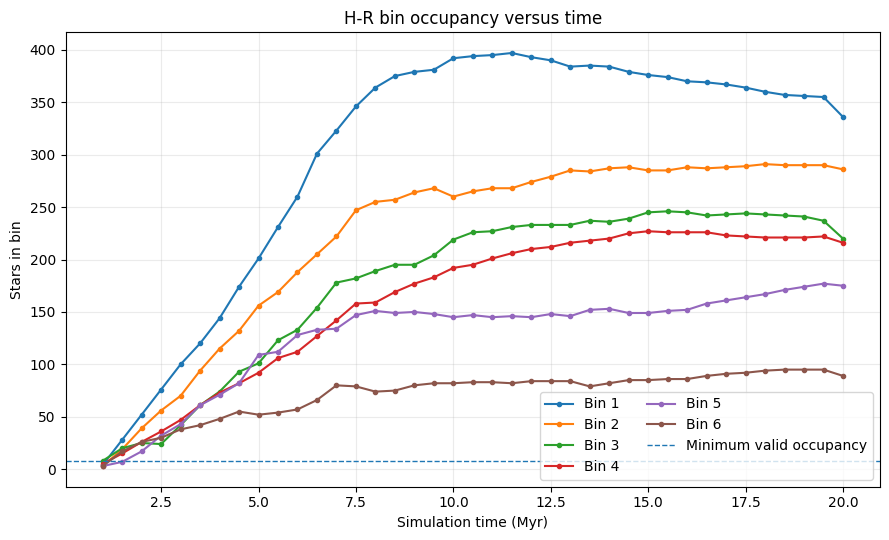

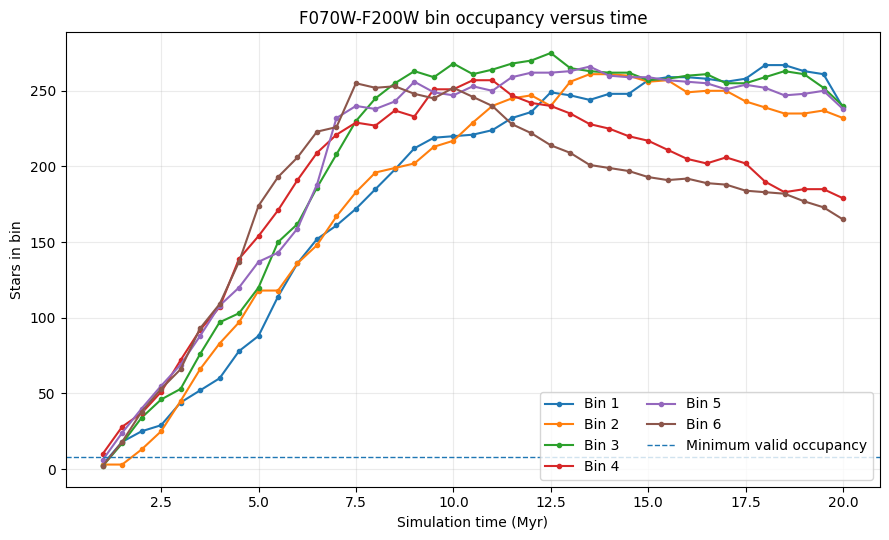

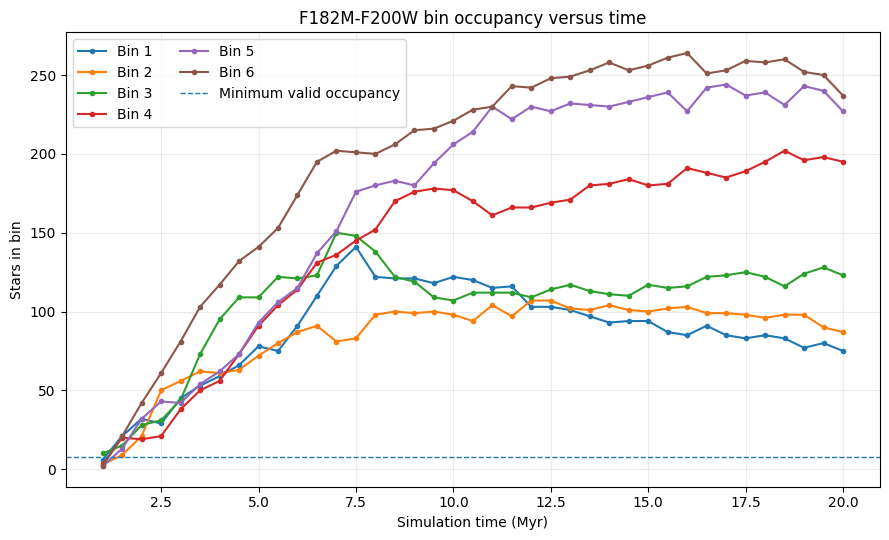

Analysis complete.
Isochrone cache: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/07-23_spread-metric-analysis-poc/isochrone_cache
Outputs: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/07-23_spread-metric-analysis-poc/cmd_spread_outputs


In [12]:
def plot_bin_occupancy(df_bins, space):
    sub = df_bins[df_bins['space'] == space]
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for i in sorted(sub['bin'].unique()):
        d = sub[sub['bin'] == i].sort_values('time_myr')
        ax.plot(d['time_myr'], d['bin_count'], marker='o', ms=3, label=f'Bin {i}')
    ax.axhline(MIN_STARS_PER_BIN, ls='--', lw=1.0, label='Minimum valid occupancy')
    ax.set(xlabel='Simulation time (Myr)', ylabel='Stars in bin', title=f'{space} bin occupancy versus time')
    ax.grid(alpha=0.25); ax.legend(ncol=2); fig.tight_layout()
    finish_figure(fig, f"diagnostic_{space.lower().replace(' ', '_').replace('-', '_')}_occupancy.png")


for _space in ['H-R', 'F070W-F200W', 'F182M-F200W']:
    plot_bin_occupancy(df_spread_bins, _space)

print('Analysis complete.')
print('Isochrone cache:', ISO_CACHE_DIR)
print('Outputs:', OUTPUT_DIR)